# **Manual way of using Adaboost**

In [24]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from mlxtend.plotting import plot_decision_regions
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree


import warnings
warnings.filterwarnings('ignore')

In [25]:
df = pd.DataFrame()

df['X1'] = [1,2,3,4,5,6,6,7,9,9]
df['X2'] = [5,3,6,8,1,9,5,8,9,2]
df['label'] = [1,1,0,1,0,1,0,1,0,0]

df.head()


,X1,X2,label
0,1,5,1
1,2,3,1
2,3,6,0
3,4,8,1
4,5,1,0


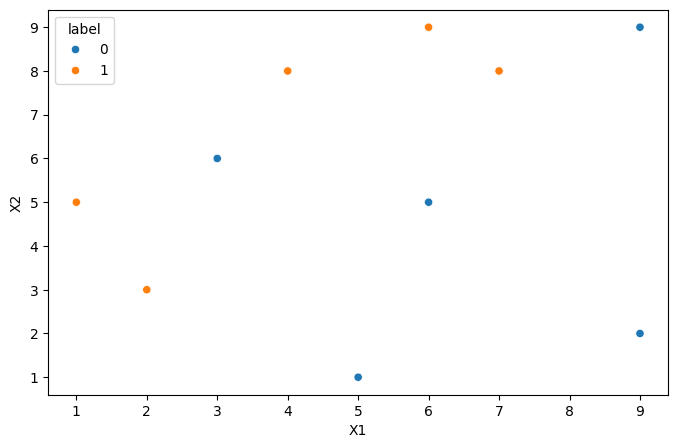

In [26]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df['X1'], y=df['X2'], hue=df['label'])
plt.show()

In [27]:
print(df.shape)

# assigning weights
df['weights'] = 1/df.shape[0]
df.head()

(10, 3)


,X1,X2,label,weights
0,1,5,1,0.1
1,2,3,1,0.1
2,3,6,0,0.1
3,4,8,1,0.1
4,5,1,0,0.1


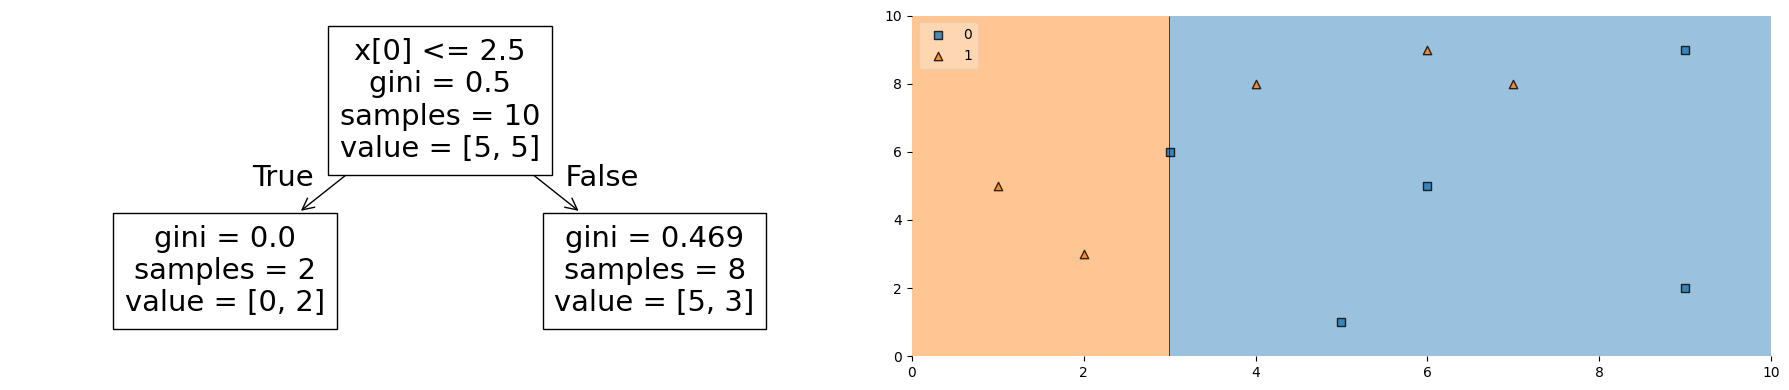

In [28]:
dt1 = DecisionTreeClassifier(max_depth=1)       # make sure to keep max_depth=1 while using adaBoost, coz in ada boost decision trees are not actually decision tree, rather they are actuallly 'Decision Stumps'

X = df.iloc[:, 0:2].values
y= df.iloc[:, 2].values

dt1.fit(X, y)
df['y_pred'] = dt1.predict(X)

plt.figure(figsize=(18, 4))
plt.subplot(1,2,1)
plot_tree(dt1);
plt.subplot(1,2,2)
plot_decision_regions(X, y, clf=dt1, legend=2)
plt.tight_layout()
plt.show()

In [29]:
df   # compare the label and y_pred to see the errors btwn training and predictin data


,X1,X2,label,weights,y_pred
0,1,5,1,0.1,1
1,2,3,1,0.1,1
2,3,6,0,0.1,0
3,4,8,1,0.1,0
4,5,1,0,0.1,0
5,6,9,1,0.1,0
6,6,5,0,0.1,0
7,7,8,1,0.1,0
8,9,9,0,0.1,0
9,9,2,0,0.1,0


In [30]:
# printing the rows where the predictions are wrong
df[df['label'] != df['y_pred']]


,X1,X2,label,weights,y_pred
3,4,8,1,0.1,0
5,6,9,1,0.1,0
7,7,8,1,0.1,0


In [31]:
# calculating weights
def calculate_model_weight(error):
    return 0.5 * np.log((1-error) / (error))        # formula for calculating error


# updating weights
def update_row_weights(row, alpha=0.423):
    if row['label'] == row['y_pred']:
        return row['weights'] * np.exp(-alpha)
    else:
        return row['weights'] * np.exp(alpha)


alpha1 = calculate_model_weight(0.3)
print(alpha1)

df['updated_weights'] = df.apply(update_row_weights, axis=1)
df.head()

0.42364893019360184


,X1,X2,label,weights,y_pred,updated_weights
0,1,5,1,0.1,1,0.065508
1,2,3,1,0.1,1,0.065508
2,3,6,0,0.1,0,0.065508
3,4,8,1,0.1,0,0.152653
4,5,1,0,0.1,0,0.065508


In [36]:
print(df['updated_weights'].sum())

df['normalized_weights'] = df['updated_weights'] / df['updated_weights'].sum()      # formula for normalized weights
print(df['normalized_weights'].sum())

df.head()

0.9165153319682015
1.0


,X1,X2,label,weights,y_pred,updated_weights,normalized_weights
0,1,5,1,0.1,1,0.065508,0.071475
1,2,3,1,0.1,1,0.065508,0.071475
2,3,6,0,0.1,0,0.065508,0.071475
3,4,8,1,0.1,0,0.152653,0.166559
4,5,1,0,0.1,0,0.065508,0.071475


In [37]:
df['cumsum_upper'] = np.cumsum(df['normalized_weights'])
df['cumsum_lower'] = df['cumsum_upper'] - df['normalized_weights']
df[['X1','X2','label','weights','y_pred','updated_weights','cumsum_lower','cumsum_upper']]

,X1,X2,label,weights,y_pred,updated_weights,cumsum_lower,cumsum_upper
0,1,5,1,0.1,1,0.065508,0.000000,0.071475
1,2,3,1,0.1,1,0.065508,0.071475,0.142950
2,3,6,0,0.1,0,0.065508,0.142950,0.214425
3,4,8,1,0.1,0,0.152653,0.214425,0.380983
4,5,1,0,0.1,0,0.065508,0.380983,0.452458
5,6,9,1,0.1,0,0.152653,0.452458,0.619017
6,6,5,0,0.1,0,0.065508,0.619017,0.690492
7,7,8,1,0.1,0,0.152653,0.690492,0.857050
8,9,9,0,0.1,0,0.065508,0.857050,0.928525
9,9,2,0,0.1,0,0.065508,0.928525,1.000000


In [38]:
df

,X1,X2,label,weights,y_pred,updated_weights,normalized_weights,cumsum_upper,cumsum_lower
0,1,5,1,0.1,1,0.065508,0.071475,0.071475,0.000000
1,2,3,1,0.1,1,0.065508,0.071475,0.142950,0.071475
2,3,6,0,0.1,0,0.065508,0.071475,0.214425,0.142950
3,4,8,1,0.1,0,0.152653,0.166559,0.380983,0.214425
4,5,1,0,0.1,0,0.065508,0.071475,0.452458,0.380983
5,6,9,1,0.1,0,0.152653,0.166559,0.619017,0.452458
6,6,5,0,0.1,0,0.065508,0.071475,0.690492,0.619017
7,7,8,1,0.1,0,0.152653,0.166559,0.857050,0.690492
8,9,9,0,0.1,0,0.065508,0.071475,0.928525,0.857050
9,9,2,0,0.1,0,0.065508,0.071475,1.000000,0.928525


In [39]:
def create_new_dataset(df):

  indices = []

  for i in range(df.shape[0]):
    a = np.random.random()
    for index,row in df.iterrows():
      if row['cumsum_upper'] > a and a > row['cumsum_lower']:
        indices.append(index)
  return indices

In [46]:
# Loop until we get a sample with more than one class to ensure meaningful plotting
while True:
    index_values = create_new_dataset(df)
    second_df = df.iloc[index_values, [0,1,2,3]]
    
    if second_df['label'].nunique() > 1:
        print("Selected indices:", index_values)
        break
        
print()
print(second_df)


Selected indices: [3, 2, 2, 6, 6, 2, 3, 7, 9, 7]

   X1  X2  label  weights
3   4   8      1      0.1
2   3   6      0      0.1
2   3   6      0      0.1
6   6   5      0      0.1
6   6   5      0      0.1
2   3   6      0      0.1
3   4   8      1      0.1
7   7   8      1      0.1
9   9   2      0      0.1
7   7   8      1      0.1


In [14]:
for index, row in df.iterrows():  
    print(row)     #  it will print the data of every column for every single row
    if index == 3:
        break

X1                    1.000000
X2                    5.000000
label                 1.000000
weights               0.100000
y_pred                1.000000
updated_weights       0.065508
normalized_weights    0.071475
cumsum_upper          0.071475
cumsum_lower          0.000000
Name: 0, dtype: float64
X1                    2.000000
X2                    3.000000
label                 1.000000
weights               0.100000
y_pred                1.000000
updated_weights       0.065508
normalized_weights    0.071475
cumsum_upper          0.142950
cumsum_lower          0.071475
Name: 1, dtype: float64
X1                    3.000000
X2                    6.000000
label                 0.000000
weights               0.100000
y_pred                1.000000
updated_weights       0.152653
normalized_weights    0.166559
cumsum_upper          0.309508
cumsum_lower          0.142950
Name: 2, dtype: float64
X1                    4.000000
X2                    8.000000
label                 1.00000

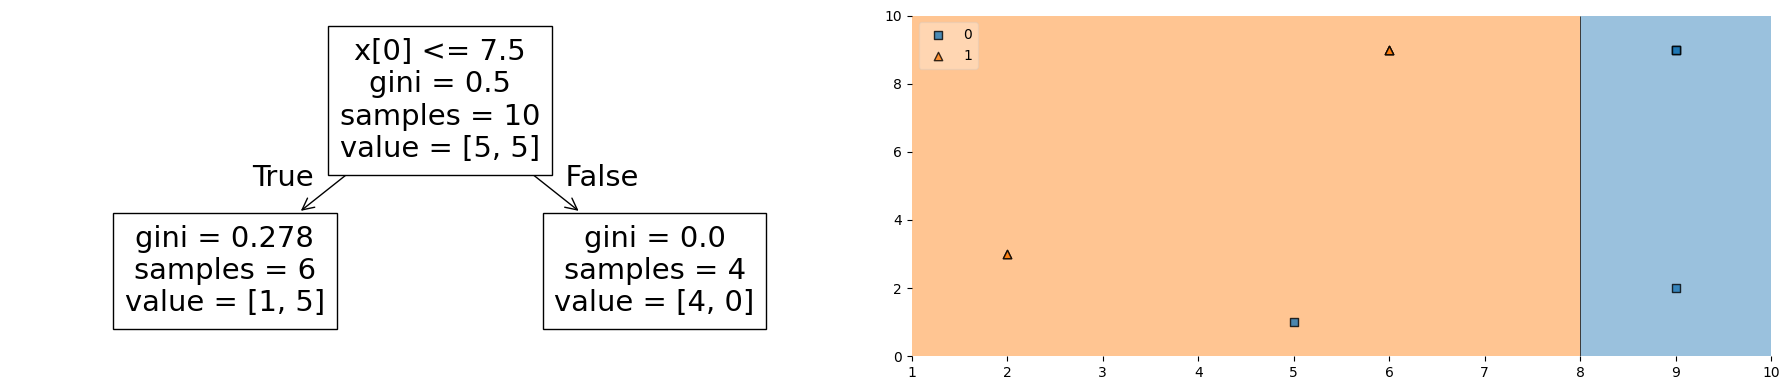

In [15]:
dt2 = DecisionTreeClassifier(max_depth=1)

X = second_df.iloc[:, 0:2].values
y = second_df.iloc[:, 2].values

dt2.fit(X, y)
second_df['y_pred'] = dt2.predict(X)

plt.figure(figsize=(18,4))
plt.subplot(1,2,1)
plot_tree(dt2);
plt.subplot(1,2,2)
plot_decision_regions(X, y, clf=dt2, legend=2)
plt.tight_layout()
plt.show()


In [16]:
second_df.head()

,X1,X2,label,weights,y_pred
1,2,3,1,0.1,1
9,9,2,0,0.1,0
5,6,9,1,0.1,1
1,2,3,1,0.1,1
8,9,9,0,0.1,0


In [17]:
alpha2 = calculate_model_weight(0.1)
print(alpha2)

1.0986122886681098


In [18]:
# updating weights

def update_row_weights(row, alpha=1.09):
    if row['label'] == row['y_pred']:
        return row['weights'] * np.exp(-alpha)
    else:
        return row['weights'] * np.exp(alpha)

second_df['updated_weights'] = second_df.apply(update_row_weights, axis=1)
second_df['nomalized_weights'] = second_df['updated_weights']/second_df['updated_weights'].sum()

print(second_df['nomalized_weights'].sum())

second_df['cumsum_upper'] = np.cumsum(second_df['nomalized_weights'])
second_df['cumsum_lower'] = second_df['cumsum_upper'] - second_df['nomalized_weights']


second_df.head()

0.9999999999999999


,X1,X2,label,weights,y_pred,updated_weights,nomalized_weights,cumsum_upper,cumsum_lower
1,2,3,1,0.1,1,0.033622,0.056034,0.056034,0.000000
9,9,2,0,0.1,0,0.033622,0.056034,0.112068,0.056034
5,6,9,1,0.1,1,0.033622,0.056034,0.168102,0.112068
1,2,3,1,0.1,1,0.033622,0.056034,0.224136,0.168102
8,9,9,0,0.1,0,0.033622,0.056034,0.280170,0.224136


In [19]:
index_values = create_new_dataset(second_df)

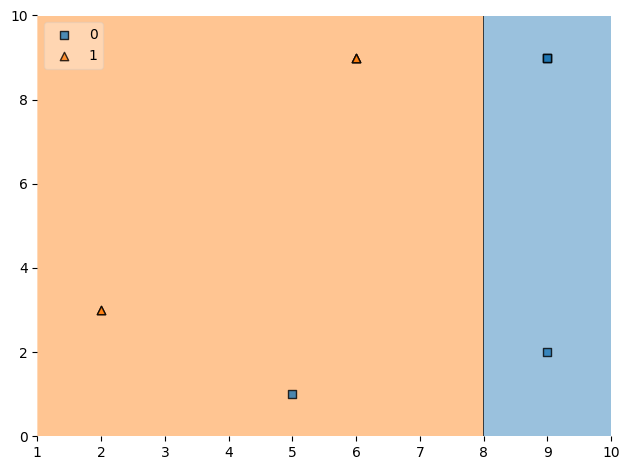

In [20]:
third_df = second_df.iloc[index_values,[0,1,2,3]]

dt3 = DecisionTreeClassifier(max_depth=1)

X = second_df.iloc[:,0:2].values
y = second_df.iloc[:,2].values

dt3.fit(X,y)
third_df['y_pred'] = dt3.predict(X)

# plt.figure(figsize=(18,4))
plot_decision_regions(X, y, clf=dt3, legend=2)
plt.tight_layout()
plt.show()

In [21]:
alpha3 = calculate_model_weight(0.7)
print(alpha3)

-0.4236489301936017


In [22]:
print(alpha1,alpha2,alpha3)

query = np.array([1,5]).reshape(1,2)

print(dt1.predict(query))
print(dt2.predict(query))
print(dt3.predict(query))
print()

ans1 = alpha1*1 + alpha2*(1) + alpha3*(1)
print(ans1)
print(np.sign(1.09))

0.42364893019360184 1.0986122886681098 -0.4236489301936017
[1]
[1]
[1]

1.09861228866811
1.0


In [23]:
query = np.array([9,9]).reshape(1,2)

print(dt1.predict(query))
print(dt2.predict(query))
print(dt3.predict(query))
print()

ans2 = alpha1*(1) + alpha2*(-1) + alpha3*(-1)
print(ans2)
print(np.sign(-0.25))

[1]
[0]
[0]

-0.2513144282809062
-1.0
